## Adversarial Autoencoder (AAE) on MNIST

This notebook will guide you through implementing an Adversarial Autoencoder (AAE) on the MNIST dataset. An AAE combines the reconstruction capabilities of an autoencoder with the adversarial training of a Generative Adversarial Network (GAN) to encourage the latent space to conform to a desired prior distribution (e.g., a Gaussian distribution).

### 1. Setup and Data Loading

First, we'll import the necessary libraries, including TensorFlow/Keras for building the neural networks, and load the MNIST dataset.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to add a channel dimension (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Define dataset parameters
IMAGE_SHAPE = x_train.shape[1:]  # (28, 28, 1)
LATENT_DIM = 100 # Dimension of the latent space
BATCH_SIZE = 128

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2. Build the AAE Models

An AAE consists of three main components:
1.  **Encoder (Recognition Network):** Maps input data to a latent space representation.
2.  **Decoder (Generative Network):** Reconstructs data from the latent space representation.
3.  **Discriminator (Adversarial Network):** Distinguishes between samples from the encoder's latent space and samples from a prior distribution.

#### 2.1 Encoder Model

In [3]:
LATENT_DIM = 100
IMAGE_SHAPE = (28, 28, 1)

def build_encoder(latent_dim, image_shape):
    encoder_inputs = tf.keras.Input(shape=image_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', strides=(2, 2), padding='same')(encoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', strides=(2, 2), padding='same')(x) # Added layer
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x) # Increased dense layer units
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    z = layers.Dense(latent_dim, name='latent_vec')(x)
    return models.Model(encoder_inputs, z, name='encoder')

encoder = build_encoder(LATENT_DIM, IMAGE_SHAPE)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vec (Dense)              │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,836 (2.46 MB)

 Trainable params: 643,876 (2.46 MB)

 Non-trainable params: 960 (3.75 KB)

#### 2.2 Decoder Model

In [4]:
def build_decoder(latent_dim, image_shape):
    decoder_inputs = tf.keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', strides=(2, 2), padding='same')(x) # This layer should now output 28x28
    x = layers.BatchNormalization()(x)
    # Removed the extra Conv2DTranspose(32, ...) layer that was causing the 56x56 output
    decoder_outputs = layers.Conv2D(image_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)
    return models.Model(decoder_inputs, decoder_outputs, name='decoder')

decoder = build_decoder(LATENT_DIM, IMAGE_SHAPE)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 881,281 (3.36 MB)

 Trainable params: 868,353 (3.31 MB)

 Non-trainable params: 12,928 (50.50 KB)

#### 2.3 Discriminator Model

The discriminator takes a latent vector as input and outputs a probability indicating whether the vector came from the encoder's output or from a true prior distribution (e.g., a Gaussian distribution).

In [5]:
def build_discriminator(latent_dim):
    discriminator_inputs = tf.keras.Input(shape=(latent_dim,))
    x = layers.Dense(256, activation='relu')(discriminator_inputs) # Increased dense layer units
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    x = layers.Dense(256, activation='relu')(x) # Increased dense layer units
    x = layers.BatchNormalization()(x) # Added BatchNormalization
    discriminator_outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(discriminator_inputs, discriminator_outputs, name='discriminator')

discriminator = build_discriminator(LATENT_DIM)
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,953 (367.00 KB)

 Trainable params: 92,929 (363.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

### 3. Compile the AAE Models

We need to compile the individual models and create a combined AAE model for training. The AAE has two main training phases:
1.  **Autoencoder Training:** The encoder and decoder are trained to reconstruct the input images. The discriminator is not involved in this phase.
2.  **Adversarial Training:** The discriminator is trained to distinguish between real latent samples (from a prior distribution) and fake latent samples (from the encoder's output). Simultaneously, the encoder is trained to fool the discriminator, making its latent output look like real prior samples.

#### 3.1 Optimizer and Loss Functions

In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    # Use soft labels for real (0.9) and fake (0.1) for stability
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output) * 0.1, fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    # Generator tries to make fake look real (label 0.9)
    return cross_entropy(tf.ones_like(fake_output) * 0.9, fake_output)

def reconstruction_loss(images, reconstructions):
    return tf.reduce_mean(tf.square(images - reconstructions))

# Hyperparameter for autoencoder loss weighting
AE_WEIGHT = 10.0 # Increased weight for reconstruction loss

# Optimizers
encoder_optimizer = tf.keras.optimizers.Adam(2e-4)
decoder_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

#### 3.2 Define the AAE Training Step

Since AAE training involves a GAN-like adversarial process, we will define a custom training step using `tf.GradientTape`.

In [7]:
@tf.function
def train_step(images):
    # ----------------------------------
    # Phase 1: Train Autoencoder (Encoder + Decoder for Reconstruction)
    # ----------------------------------
    with tf.GradientTape(persistent=True) as ae_tape: # Make ae_tape persistent
        latent_vec = encoder(images)
        reconstructions = decoder(latent_vec)
        ae_loss = reconstruction_loss(images, reconstructions)

    gradients_of_encoder = ae_tape.gradient(ae_loss, encoder.trainable_variables)
    gradients_of_decoder = ae_tape.gradient(ae_loss, decoder.trainable_variables)
    del ae_tape # Delete the tape to release resources

    encoder_optimizer.apply_gradients(zip(gradients_of_encoder, encoder.trainable_variables))
    decoder_optimizer.apply_gradients(zip(gradients_of_decoder, decoder.trainable_variables))

    # ----------------------------------
    # Phase 2: Train Discriminator
    # ----------------------------------
    with tf.GradientTape() as disc_tape:
        # Sample from prior distribution (e.g., standard normal)
        random_latent_vectors = tf.random.normal(shape=(BATCH_SIZE, LATENT_DIM))

        # Get latent vectors from encoder (fake samples for discriminator)
        encoder_latent_vectors = encoder(images)

        real_output = discriminator(random_latent_vectors)
        fake_output = discriminator(encoder_latent_vectors)

        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # ----------------------------------
    # Phase 3: Train Encoder (as Generator to fool Discriminator)
    # ----------------------------------
    with tf.GradientTape() as gen_tape:
        latent_vec = encoder(images)
        reconstructions_gen = decoder(latent_vec) # Also reconstruct for AE loss contribution
        fake_output_for_generator = discriminator(latent_vec)

        # Combined loss for encoder: Generator loss + Weighted Reconstruction loss
        gen_loss = generator_loss(fake_output_for_generator)
        # Apply AE_WEIGHT to the reconstruction loss part of the encoder's training
        ae_recon_loss_for_gen = reconstruction_loss(images, reconstructions_gen)
        encoder_total_loss = gen_loss + AE_WEIGHT * ae_recon_loss_for_gen

    gradients_of_generator = gen_tape.gradient(encoder_total_loss, encoder.trainable_variables)
    encoder_optimizer.apply_gradients(zip(gradients_of_generator, encoder.trainable_variables))

    return ae_loss, disc_loss, gen_loss

### 4. Training Loop

Now, we will implement the full training loop, including iterating over epochs and visualizing reconstruction and latent space samples during training.


Epoch 1/50
  AE Loss: 0.0794, Discriminator Loss: 5.4924, Generator Loss: 0.7220
Generating images for epoch 1...


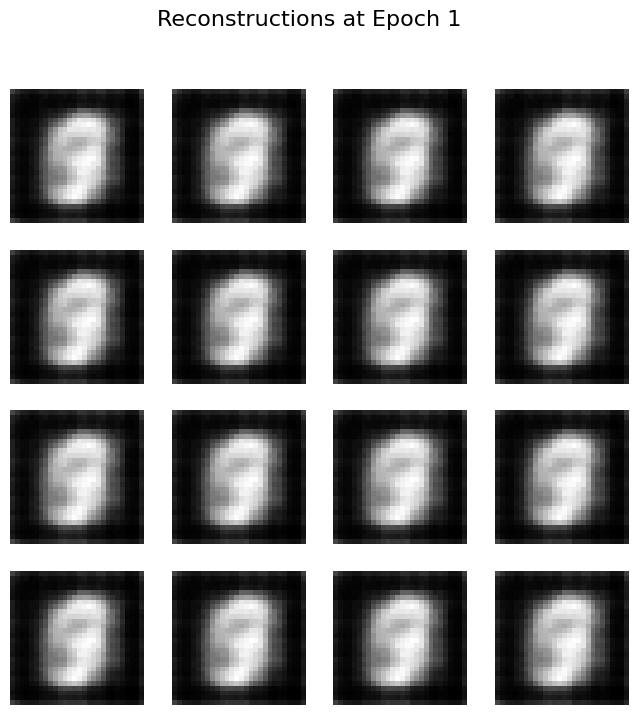


Epoch 2/50
  AE Loss: 0.0609, Discriminator Loss: 2.7669, Generator Loss: 0.5909

Epoch 3/50
  AE Loss: 0.0471, Discriminator Loss: 2.0746, Generator Loss: 0.5585

Epoch 4/50
  AE Loss: 0.0406, Discriminator Loss: 1.7656, Generator Loss: 0.6278

Epoch 5/50
  AE Loss: 0.0351, Discriminator Loss: 1.6983, Generator Loss: 0.6604
Generating images for epoch 5...


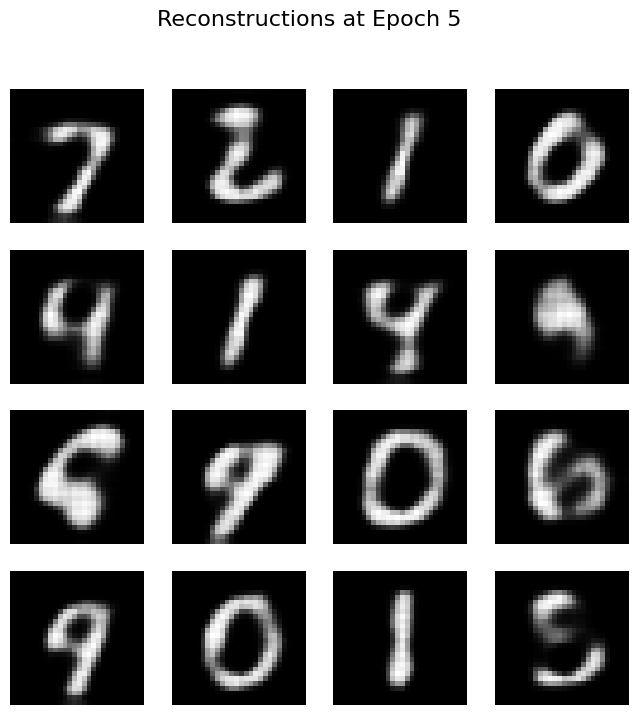


Epoch 6/50
  AE Loss: 0.0346, Discriminator Loss: 1.5918, Generator Loss: 0.7047

Epoch 7/50
  AE Loss: 0.0301, Discriminator Loss: 1.5805, Generator Loss: 0.6917

Epoch 8/50
  AE Loss: 0.0320, Discriminator Loss: 1.5135, Generator Loss: 0.7511

Epoch 9/50
  AE Loss: 0.0345, Discriminator Loss: 1.4801, Generator Loss: 0.7763

Epoch 10/50
  AE Loss: 0.0254, Discriminator Loss: 1.5219, Generator Loss: 0.7113
Generating images for epoch 10...


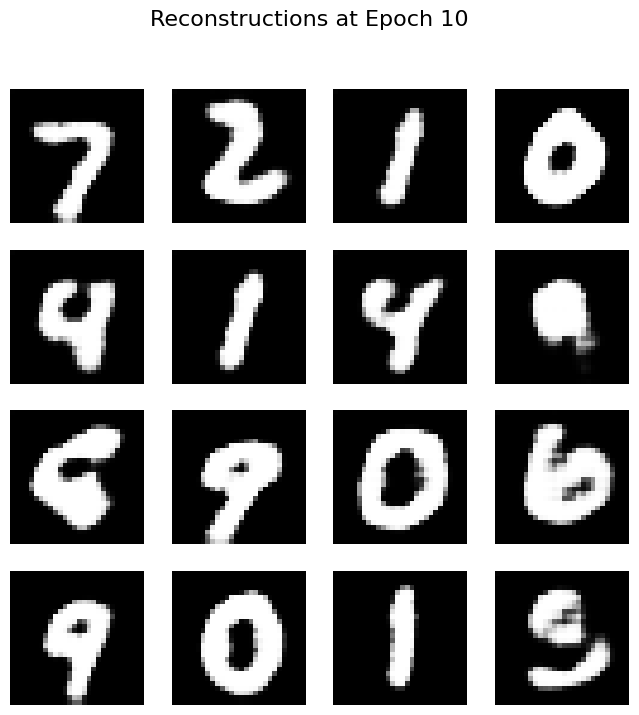


Epoch 11/50
  AE Loss: 0.0334, Discriminator Loss: 1.4874, Generator Loss: 0.7827

Epoch 12/50
  AE Loss: 0.0286, Discriminator Loss: 1.4267, Generator Loss: 0.7727

Epoch 13/50
  AE Loss: 0.0238, Discriminator Loss: 1.5284, Generator Loss: 0.7390

Epoch 14/50
  AE Loss: 0.0280, Discriminator Loss: 1.4293, Generator Loss: 0.8042

Epoch 15/50
  AE Loss: 0.0242, Discriminator Loss: 1.4767, Generator Loss: 0.7295
Generating images for epoch 15...


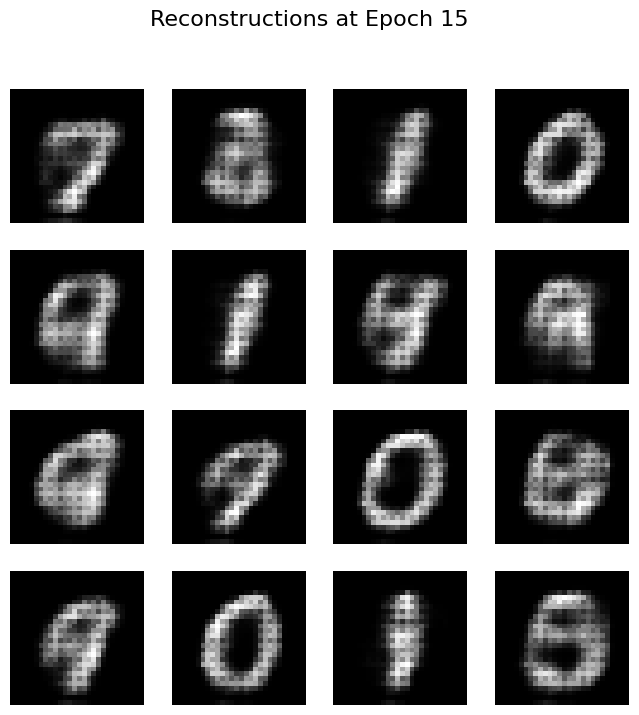


Epoch 16/50
  AE Loss: 0.0316, Discriminator Loss: 1.4088, Generator Loss: 0.8286

Epoch 17/50
  AE Loss: 0.0225, Discriminator Loss: 1.4722, Generator Loss: 0.7397

Epoch 18/50
  AE Loss: 0.0180, Discriminator Loss: 1.4540, Generator Loss: 0.7682

Epoch 19/50
  AE Loss: 0.0175, Discriminator Loss: 1.4671, Generator Loss: 0.7501

Epoch 20/50
  AE Loss: 0.0242, Discriminator Loss: 1.4259, Generator Loss: 0.7981
Generating images for epoch 20...


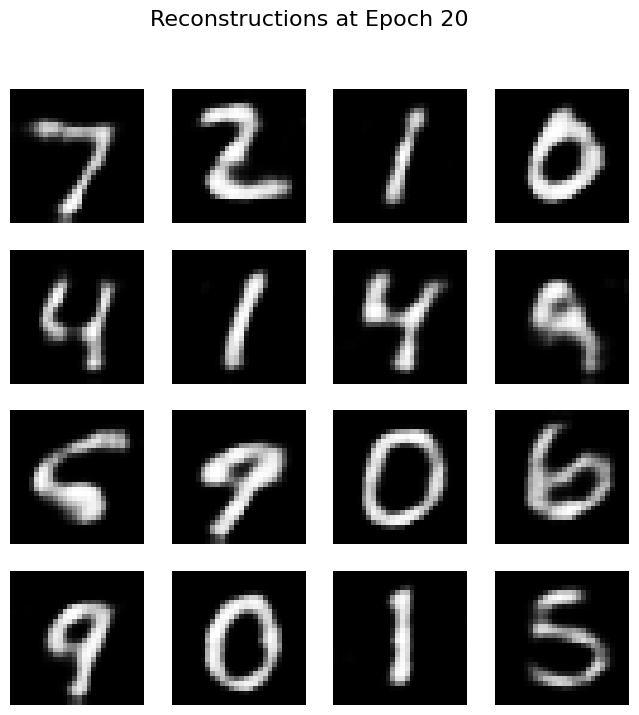


Epoch 21/50
  AE Loss: 0.0162, Discriminator Loss: 1.4398, Generator Loss: 0.7627

Epoch 22/50
  AE Loss: 0.0149, Discriminator Loss: 1.4401, Generator Loss: 0.7560

Epoch 23/50
  AE Loss: 0.0153, Discriminator Loss: 1.4660, Generator Loss: 0.7730

Epoch 24/50
  AE Loss: 0.0226, Discriminator Loss: 1.4012, Generator Loss: 0.8063

Epoch 25/50
  AE Loss: 0.0156, Discriminator Loss: 1.4706, Generator Loss: 0.7715
Generating images for epoch 25...


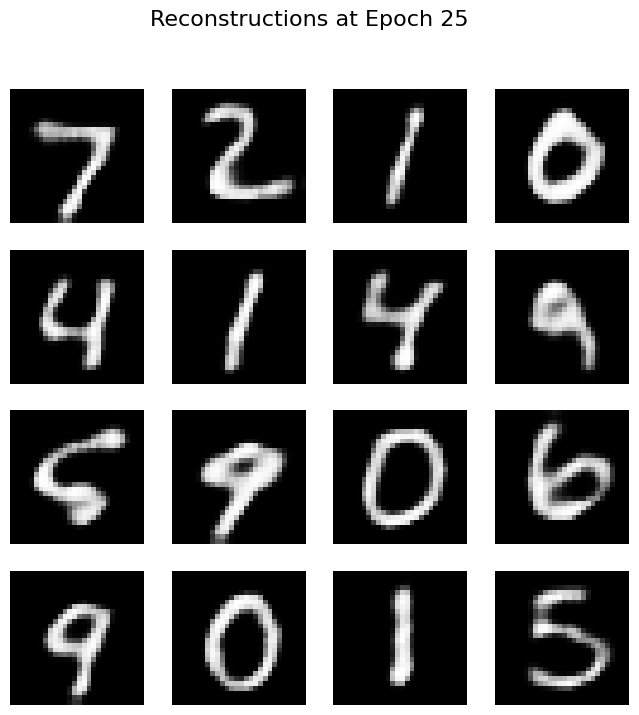


Epoch 26/50
  AE Loss: 0.0134, Discriminator Loss: 1.4529, Generator Loss: 0.7545

Epoch 27/50
  AE Loss: 0.0126, Discriminator Loss: 1.4560, Generator Loss: 0.7581

Epoch 28/50
  AE Loss: 0.0118, Discriminator Loss: 1.4513, Generator Loss: 0.7575

Epoch 29/50
  AE Loss: 0.0114, Discriminator Loss: 1.4438, Generator Loss: 0.7606

Epoch 30/50
  AE Loss: 0.0111, Discriminator Loss: 1.4220, Generator Loss: 0.7595
Generating images for epoch 30...


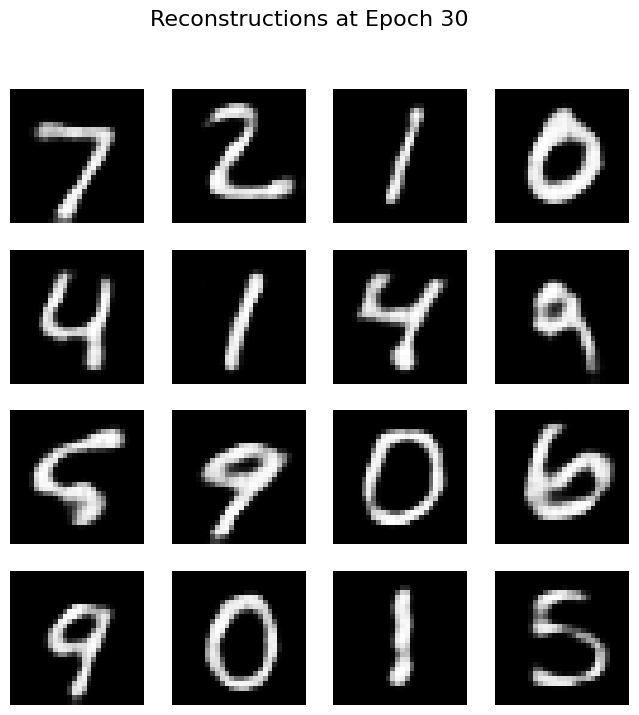


Epoch 31/50
  AE Loss: 0.0102, Discriminator Loss: 1.4379, Generator Loss: 0.7689

Epoch 32/50
  AE Loss: 0.0094, Discriminator Loss: 1.4358, Generator Loss: 0.7598

Epoch 33/50
  AE Loss: 0.0106, Discriminator Loss: 1.4181, Generator Loss: 0.7646

Epoch 34/50
  AE Loss: 0.0094, Discriminator Loss: 1.4339, Generator Loss: 0.7685

Epoch 35/50
  AE Loss: 0.0081, Discriminator Loss: 1.4068, Generator Loss: 0.7682
Generating images for epoch 35...


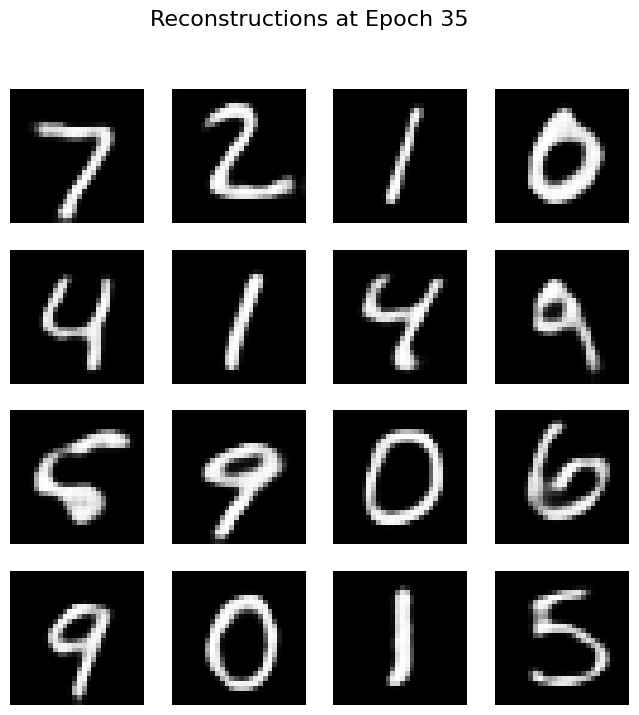


Epoch 36/50
  AE Loss: 0.0077, Discriminator Loss: 1.4143, Generator Loss: 0.7682

Epoch 37/50
  AE Loss: 0.0074, Discriminator Loss: 1.4015, Generator Loss: 0.7709

Epoch 38/50
  AE Loss: 0.0077, Discriminator Loss: 1.4132, Generator Loss: 0.7692

Epoch 39/50
  AE Loss: 0.0102, Discriminator Loss: 1.4204, Generator Loss: 0.7723

Epoch 40/50
  AE Loss: 0.0071, Discriminator Loss: 1.4153, Generator Loss: 0.7639
Generating images for epoch 40...


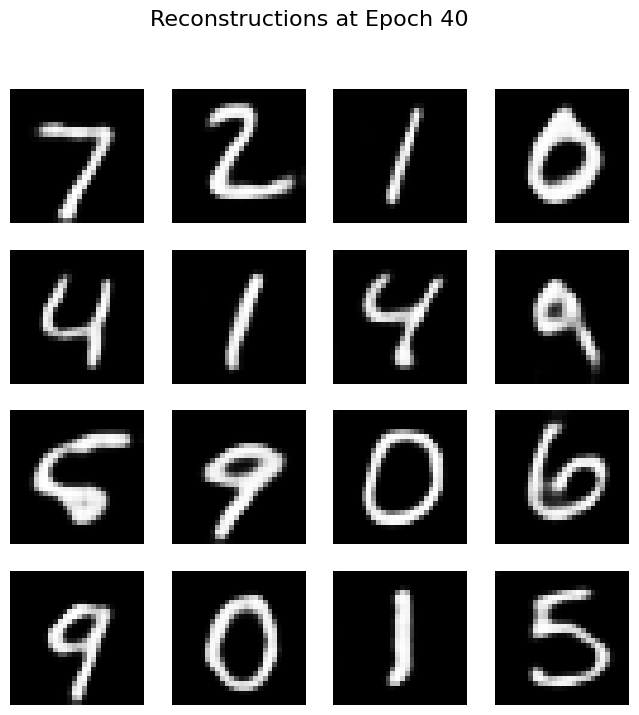


Epoch 41/50
  AE Loss: 0.0064, Discriminator Loss: 1.4047, Generator Loss: 0.7711

Epoch 42/50
  AE Loss: 0.0063, Discriminator Loss: 1.3984, Generator Loss: 0.7697

Epoch 43/50
  AE Loss: 0.0062, Discriminator Loss: 1.4114, Generator Loss: 0.7685

Epoch 44/50
  AE Loss: 0.0061, Discriminator Loss: 1.4119, Generator Loss: 0.7683

Epoch 45/50
  AE Loss: 0.0053, Discriminator Loss: 1.3941, Generator Loss: 0.7716
Generating images for epoch 45...


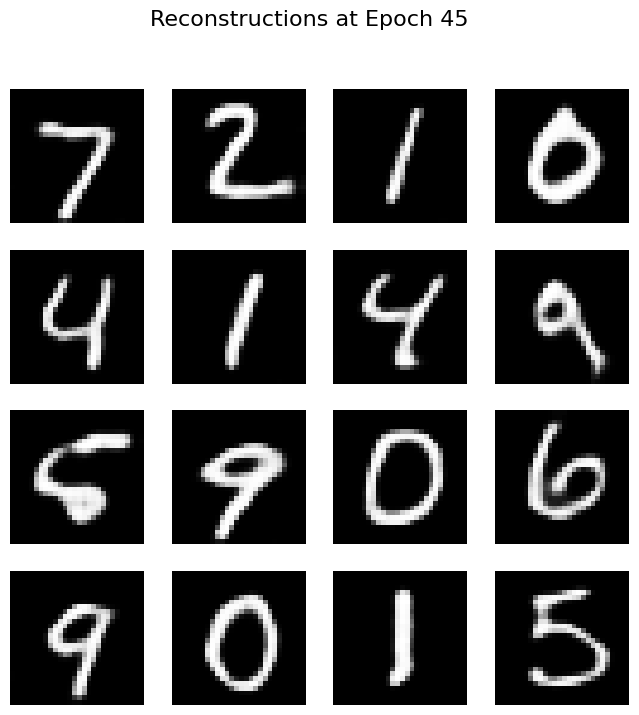


Epoch 46/50
  AE Loss: 0.0052, Discriminator Loss: 1.3956, Generator Loss: 0.7725

Epoch 47/50
  AE Loss: 0.0069, Discriminator Loss: 1.3992, Generator Loss: 0.7772

Epoch 48/50
  AE Loss: 0.0051, Discriminator Loss: 1.3940, Generator Loss: 0.7726

Epoch 49/50
  AE Loss: 0.0049, Discriminator Loss: 1.3935, Generator Loss: 0.7742

Epoch 50/50
  AE Loss: 0.0047, Discriminator Loss: 1.3891, Generator Loss: 0.7741
Generating images for epoch 50...


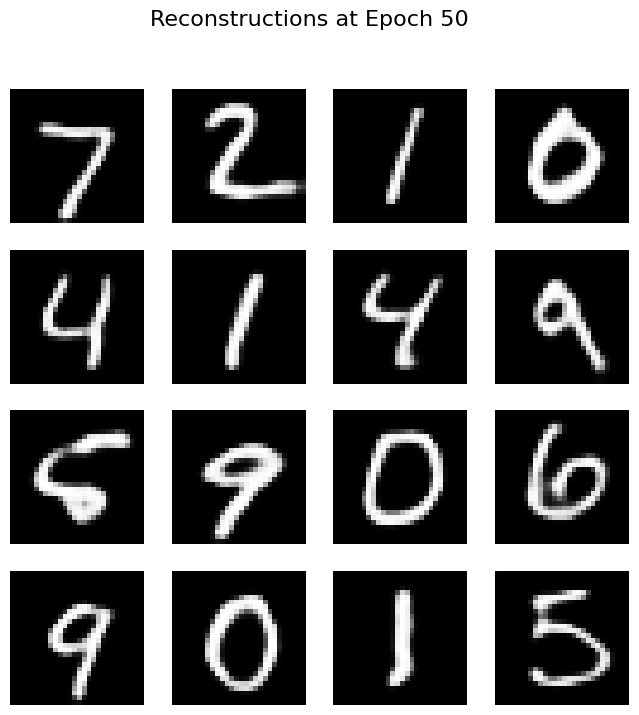


Training complete!


In [8]:
EPOCHS = 50

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 255, cmap='gray')
        plt.axis('off')

    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

# Select a fixed set of test images for visualization
# Take 16 images for visualization from the test set
for test_batch in test_dataset.take(1):
    fixed_test_images = test_batch
    break

# Training loop
for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch + 1}/{EPOCHS}')
    total_ae_loss = 0.0
    total_disc_loss = 0.0
    total_gen_loss = 0.0
    num_batches = 0

    for batch in train_dataset:
        ae_loss, disc_loss, gen_loss = train_step(batch)
        total_ae_loss += ae_loss
        total_disc_loss += disc_loss
        total_gen_loss += gen_loss
        num_batches += 1

    avg_ae_loss = total_ae_loss / num_batches
    avg_disc_loss = total_disc_loss / num_batches
    avg_gen_loss = total_gen_loss / num_batches

    print(f'  AE Loss: {avg_ae_loss:.4f}, Discriminator Loss: {avg_disc_loss:.4f}, Generator Loss: {avg_gen_loss:.4f}')

    # Generate and display images for current epoch
    if (epoch + 1) % 5 == 0 or epoch == 0: # Visualize every 5 epochs and at the beginning
        print(f'Generating images for epoch {epoch + 1}...')
        # Reconstruct test images
        latent_vectors_for_display = encoder(fixed_test_images)
        reconstructed_images = decoder(latent_vectors_for_display)

        plt.figure(figsize=(8, 8))
        plt.suptitle(f'Reconstructions at Epoch {epoch + 1}', fontsize=16)
        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(reconstructed_images[i].numpy().reshape(IMAGE_SHAPE[0], IMAGE_SHAPE[1]) * 255, cmap='gray')
            plt.axis('off')
        plt.show()

print('\nTraining complete!')

### 5. Evaluate and Visualize Results

After training, let's visualize some final results including original vs. reconstructed images and images generated from random latent vectors.

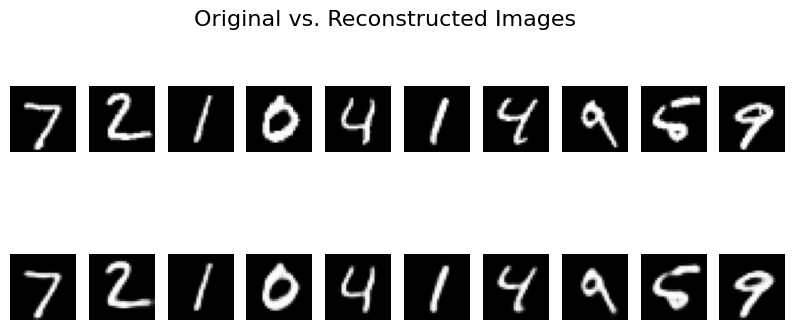

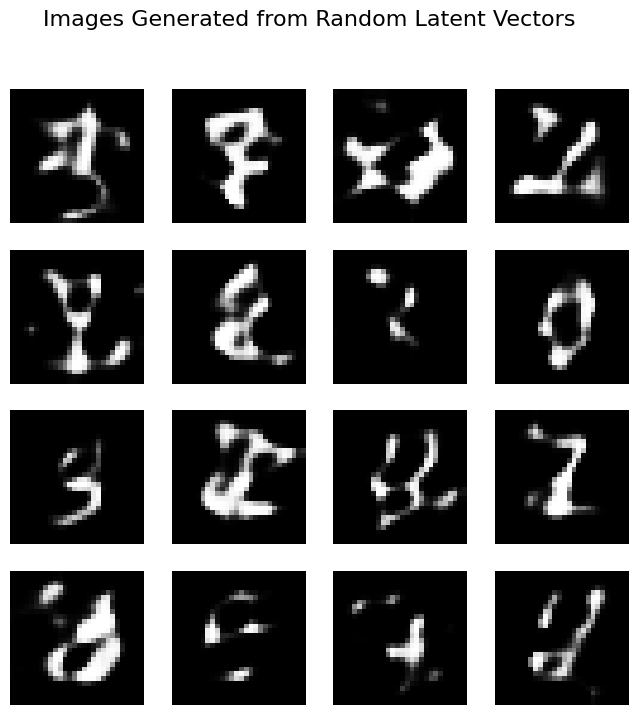

In [9]:
# 1. Visualize Original vs. Reconstructed Images

# Take a batch of images from the test dataset
for test_batch_original in test_dataset.take(1):
    break

# Encode and Decode to get reconstructions
encoded_imgs = encoder(test_batch_original)
decoded_imgs = decoder(encoded_imgs)

plt.figure(figsize=(10, 4))
plt.suptitle('Original vs. Reconstructed Images', fontsize=16)
for i in range(10):
    # Original Image
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(test_batch_original[i].numpy().reshape(IMAGE_SHAPE[0], IMAGE_SHAPE[1]) * 255, cmap='gray')
    plt.axis('off')

    # Reconstructed Image
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].numpy().reshape(IMAGE_SHAPE[0], IMAGE_SHAPE[1]) * 255, cmap='gray')
    plt.axis('off')
plt.show()

# 2. Generate Images from Random Latent Vectors

random_latent_vectors = tf.random.normal(shape=(16, LATENT_DIM))
generated_images = decoder(random_latent_vectors)

plt.figure(figsize=(8, 8))
plt.suptitle('Images Generated from Random Latent Vectors', fontsize=16)
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].numpy().reshape(IMAGE_SHAPE[0], IMAGE_SHAPE[1]) * 255, cmap='gray')
    plt.axis('off')
plt.show()